In [5]:
import os

try:
    BASE = os.path.dirname(os.path.abspath(__file__))
except NameError:
    BASE = os.getcwd()
import warnings

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.api as sm
from geodatasets import get_path
from matplotlib.patches import Ellipse
from scipy.special import expit
from sklearn.linear_model import LogisticRegression
from src.figures import save_figure

warnings.simplefilter(action='ignore', category=FutureWarning)
plt.style.use(os.path.join(BASE,"..", "configs", "visualisations.mplstyle"))

from src.data_loader import _load_disaster_data

df = _load_disaster_data(BASE)

figure_path = os.path.join(BASE, '04_figures')
if not os.path.exists(figure_path):
    os.makedirs(figure_path)

# VL 04: Logistic regression & Bayes’ classification

**Fig. 4.1** World maps of events

In [6]:
x_axis = "Longitude"
y_axis = "Latitude"
subplot_column = "Disaster Type"

cols_needed = [x_axis, y_axis, subplot_column]
df_use = df[cols_needed].copy()
df_use[y_axis] = pd.to_numeric(df_use[y_axis], errors="coerce")
df_use[x_axis] = pd.to_numeric(df_use[x_axis], errors="coerce")
df_use = df_use.dropna(subset=[x_axis, y_axis, subplot_column])
df_use = df_use[(df_use[y_axis] >= -90) & (df_use[y_axis] <= 90)]
df_use = df_use[(df_use[x_axis] >= -180) & (df_use[x_axis] <= 180)]


def _plot_disaster_map(df=df_use,  disaster = 'Volcanic activity'):
    world = gpd.read_file(get_path("naturalearth.land"))
    ax = world.plot(color="white", edgecolor="black")

    df = df[df["Disaster Type"].isin([disaster])]

    gdf = gpd.GeoDataFrame(
        df, geometry=gpd.points_from_xy(df["Longitude"], df["Latitude"]), crs="EPSG:4326"
    )
    gdf.plot(ax=ax, column="Disaster Type", categorical=True, legend=False, markersize=30, alpha=0.8)
    plt.title(f"Map {disaster} events")
    plt.xlabel("Longitude")
    plt.ylabel("Latitude")
    save_figure(4, 1, 'world_maps', variant=disaster)
    plt.show()


Saved Fig. 4.1 -> 04_figures/4.1_world_maps/4.1_world_maps_Volcanic_activity.pdf


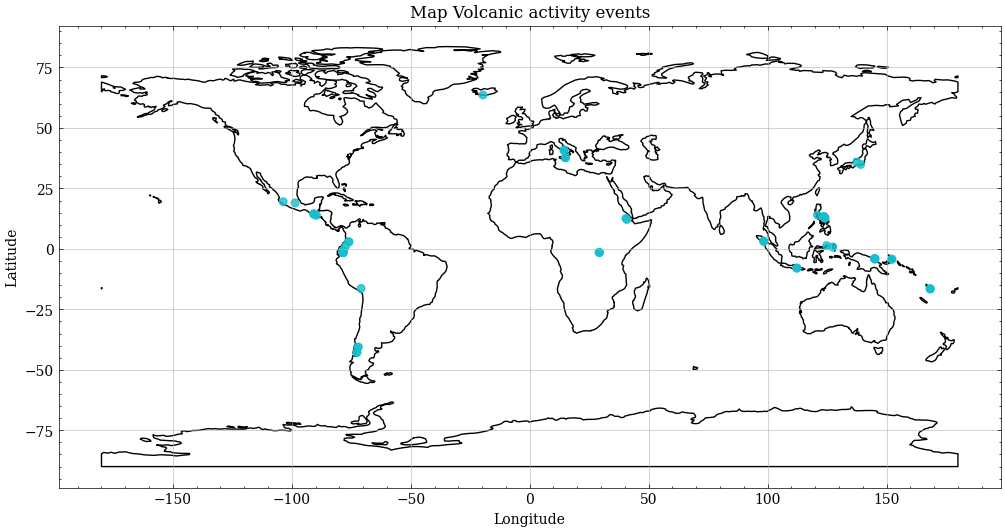

In [7]:
_plot_disaster_map(df_use,  disaster = 'Volcanic activity')

Saved Fig. 4.1 -> 04_figures/4.1_world_maps/4.1_world_maps_Storm.pdf


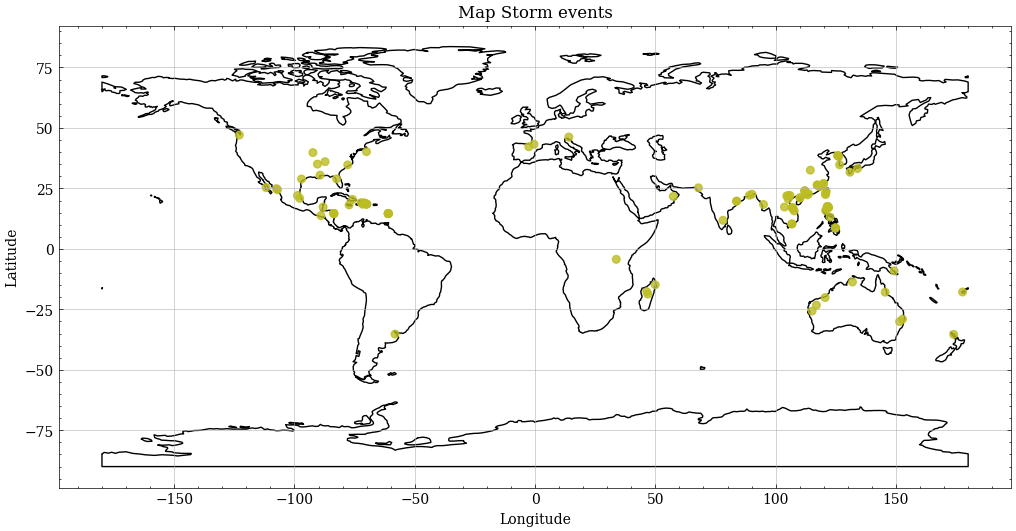

In [8]:
_plot_disaster_map(df_use,  disaster = 'Storm')

Saved Fig. 4.1 -> 04_figures/4.1_world_maps/4.1_world_maps_Landslide.pdf


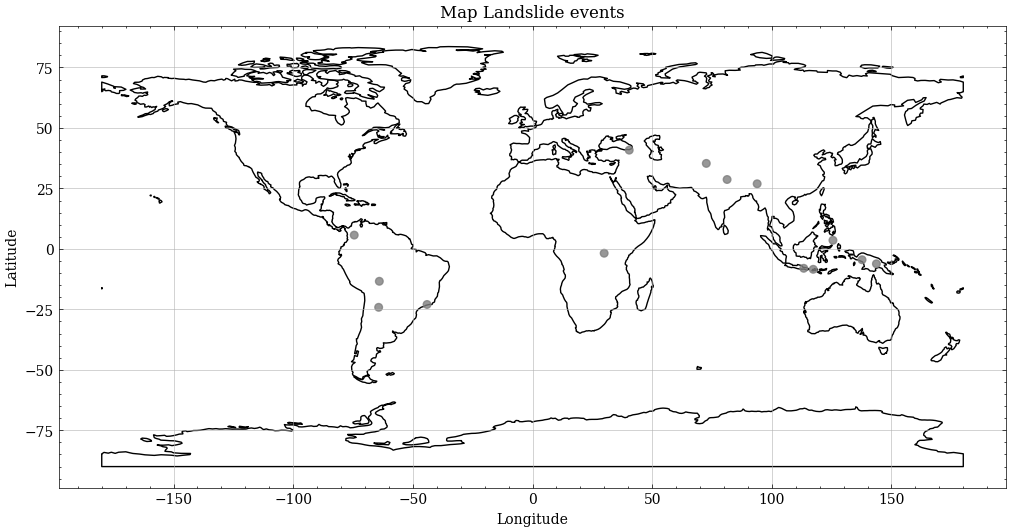

In [9]:
_plot_disaster_map(df_use,  disaster = 'Landslide')

**Fig. 4.2** Linear attempt

Saved Fig. 4.2 -> 04_figures/4.2_linear_attempt/4.2_linear_attempt_Volcanic_activity.pdf


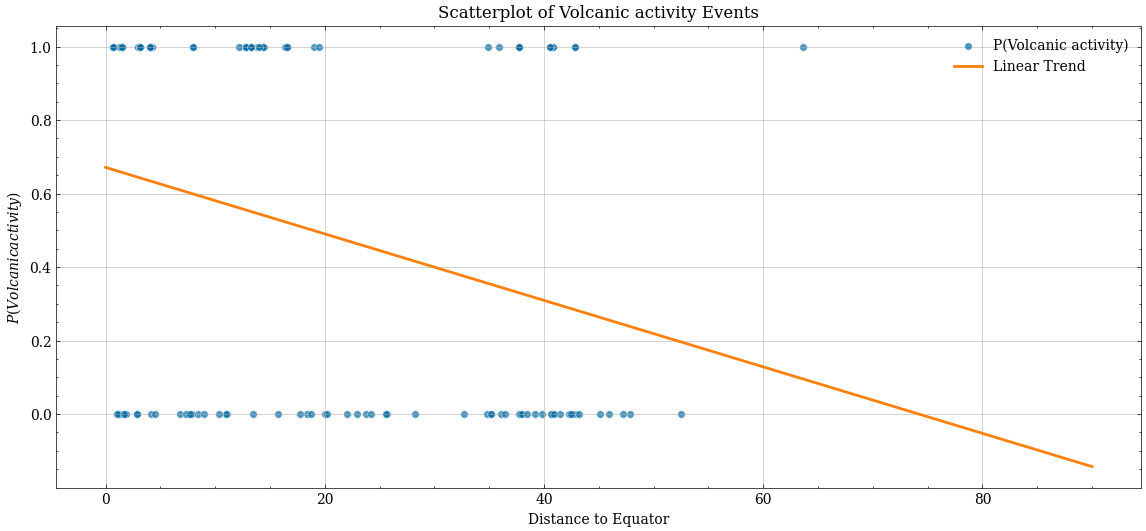

In [10]:
focus_disasters = 'Volcanic activity'
defined_colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

df_use[f"P({focus_disasters})"] = df_use["Disaster Type"].apply(lambda x: 1 if x == focus_disasters else 0)
df_use["Distance to Equator"] = df_use["Latitude"].apply(lambda x: abs(x))
df_disaster = df_use[df_use[f"P({focus_disasters})"] == 1]
df_no_disaster = df_use[df_use[f"P({focus_disasters})"] == 0].sample(n=len(df_disaster), random_state=0)
df_plot = pd.concat([df_disaster, df_no_disaster])

plt.scatter(data=df_plot, x="Distance to Equator", y=f"P({focus_disasters})", s=30, alpha=0.7, edgecolors='w', linewidth=0.5)

mask = (df_plot["Distance to Equator"] >= 0) & (df_plot[f"P({focus_disasters})"] >= 0)
x = df_plot.loc[mask, "Distance to Equator"]
y = df_plot.loc[mask, f"P({focus_disasters})"]
coefficients = np.polyfit(x, y, 1)
poly = np.poly1d(coefficients)
x_fit = np.linspace(0, 90, 100)
y_fit = poly(x_fit)
plt.plot(x_fit, y_fit, color=defined_colors[1], linewidth=2, label='Linear Trend')

plt.legend()
plt.title(f'Scatterplot of {focus_disasters} Events')
plt.xlabel('Distance to Equator')
plt.ylabel(f"$P({focus_disasters})$")
save_figure(4, 2, 'linear_attempt', variant=focus_disasters)
plt.show()

**Fig. 4.3** Logistic fit

Saved Fig. 4.3 -> 04_figures/4.3_logistic_fit/4.3_logistic_fit_Volcanic_activity_lim-180_180.pdf


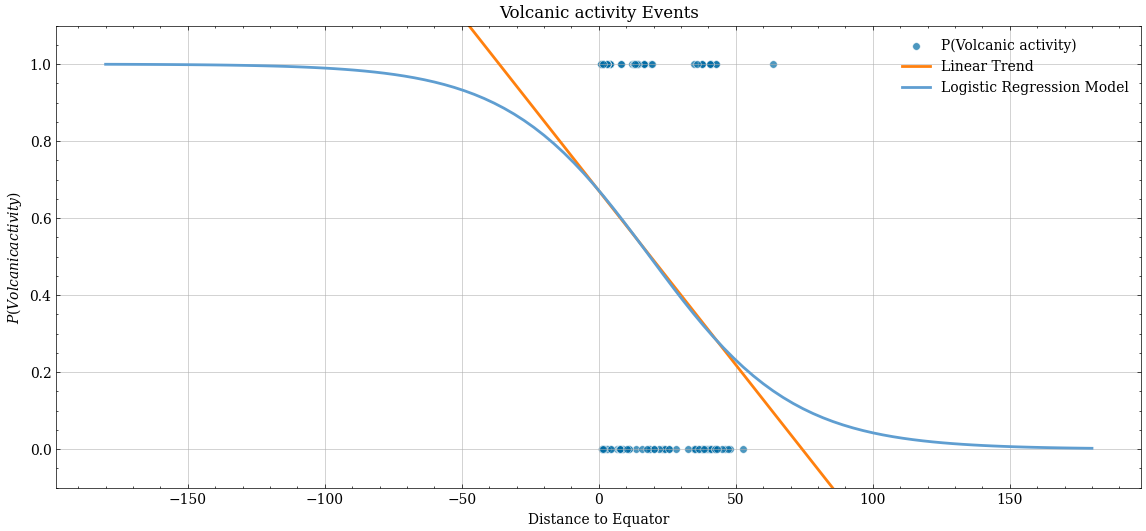

In [11]:
def plot_linear_and_logistic_regression(df_plot, focus_disasters='Volcanic activity', main_plot_limits=(-90, 90)):
    defined_colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

    df_use[f"P({focus_disasters})"] = df_use["Disaster Type"].apply(lambda x: 1 if x == focus_disasters else 0)
    df_use["Distance to Equator"] = df_use["Latitude"].apply(lambda x: abs(x))
    df_disaster = df_use[df_use[f"P({focus_disasters})"] == 1]
    df_no_disaster = df_use[df_use[f"P({focus_disasters})"] == 0].sample(n=len(df_disaster), random_state=0)
    df_plot = pd.concat([df_disaster, df_no_disaster])

    fig, ax = plt.subplots()
    ax.scatter(data=df_plot, x="Distance to Equator", y=f"P({focus_disasters})", s=30, alpha=0.7, edgecolors='w', linewidth=0.5)
    mask = (df_plot["Distance to Equator"] >= 0) & (df_plot[f"P({focus_disasters})"] >= 0)
    x = df_plot.loc[mask, "Distance to Equator"]
    y = df_plot.loc[mask, f"P({focus_disasters})"]
    X = x.values.reshape(-1, 1)

    main_plot_x = np.linspace(main_plot_limits[0], main_plot_limits[1], 100)

    coefficients = np.polyfit(x, y, 1)
    poly = np.poly1d(coefficients)
    y_fit = poly(main_plot_x)
    ax.plot(main_plot_x, y_fit, color=defined_colors[1], linewidth=2, label='Linear Trend')

    clf = LogisticRegression()
    clf.fit(X, y)
    loss = expit(main_plot_x * clf.coef_[0][0] + clf.intercept_[0]).ravel()
    ax.plot(main_plot_x, loss, label="Logistic Regression Model", color=defined_colors[4], linewidth=2)

    ax.set_title(f'{focus_disasters} Events')
    ax.set_ylim(-0.1, 1.1)
    ax.set_xlabel('Distance to Equator')
    ax.set_ylabel(f"$P({focus_disasters})$")
    ax.legend(loc='upper right')
    save_figure(4, 3, 'logistic_fit', variant=f'{focus_disasters}_lim{main_plot_limits[0]}_{main_plot_limits[1]}')
    plt.show()
    
plot_linear_and_logistic_regression(df_plot, focus_disasters='Volcanic activity', main_plot_limits=(-180, 180))

Saved Fig. 4.3 -> 04_figures/4.3_logistic_fit/4.3_logistic_fit_Volcanic_activity_lim0_90.pdf


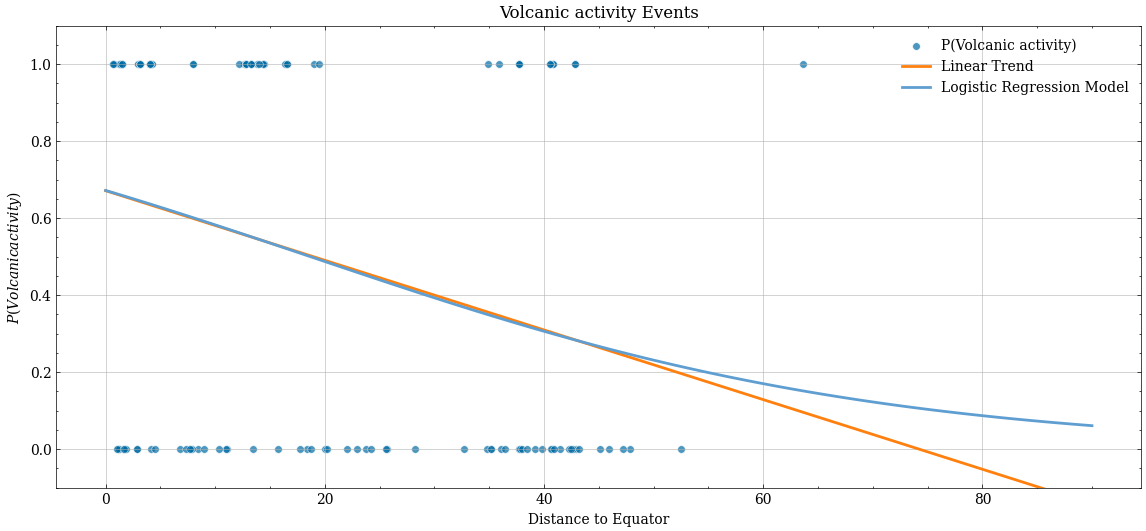

In [12]:
plot_linear_and_logistic_regression(df_plot, focus_disasters='Volcanic activity', main_plot_limits=(0, 90))

In [13]:

X = df_plot[["Distance to Equator"]]
y = df_plot[f"P({focus_disasters})"]

valid = ~(
    X.isnull().any(axis=1)
    | X.isin([np.inf, -np.inf]).any(axis=1)
    | y.isnull()
    | y.isin([np.inf, -np.inf])
)
X = X[valid]
y = y[valid]

X = sm.add_constant(X)
logit_mod = sm.Logit(y.astype(float), X.astype(float))
logit_res = logit_mod.fit()
print(logit_res.summary())

Optimization terminated successfully.
         Current function value: 0.649122
         Iterations 5
                            Logit Regression Results                            
Dep. Variable:     P(Volcanic activity)   No. Observations:                  124
Model:                            Logit   Df Residuals:                      122
Method:                             MLE   Df Model:                            1
Date:                  Wed, 12 Aug 2026   Pseudo R-squ.:                 0.06352
Time:                          12:03:46   Log-Likelihood:                -80.491
converged:                         True   LL-Null:                       -85.950
Covariance Type:              nonrobust   LLR p-value:                 0.0009522
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                   0.7163      0.290      2.474      0.013       0.14

**Fig. 4.4** Class priors

Saved Fig. 4.4 -> 04_figures/4.4_class_prior/4.4_class_prior_unfitted.pdf


/var/folders/ct/qpfxjbdn1xx4fvb2v099sg_00000gn/T/ipykernel_29902/2606032582.py:18: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


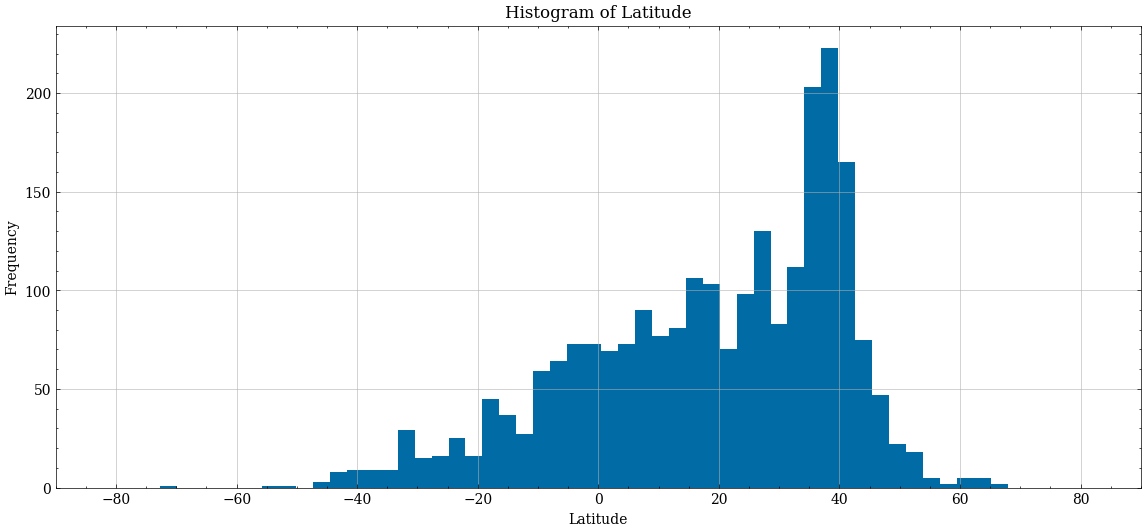

Saved Fig. 4.4 -> 04_figures/4.4_class_prior/4.4_class_prior_fitted.pdf


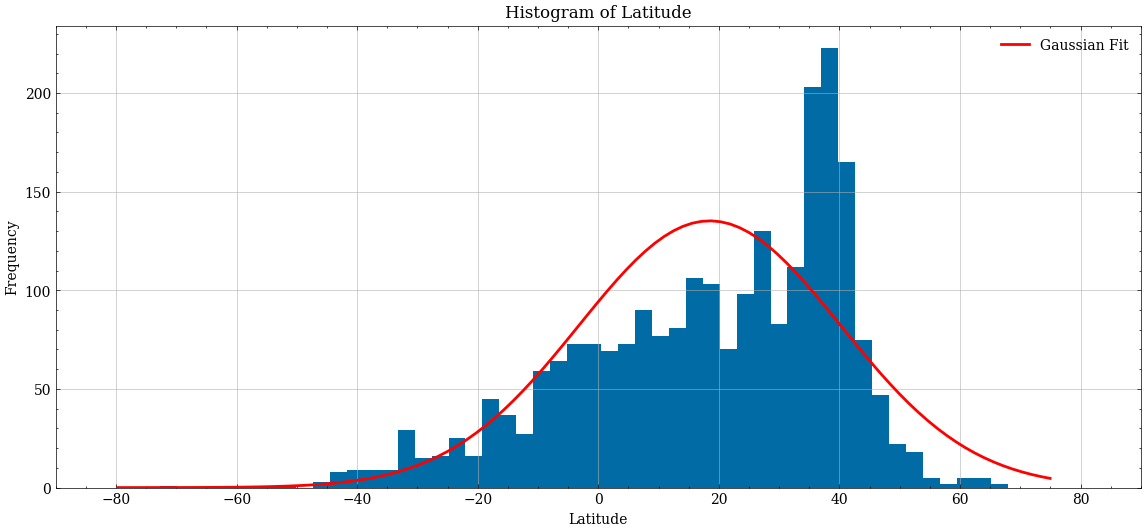

In [20]:
def _plot_prior(show_prior=True):
    plt.figure()
    plt.title("Histogram of Latitude")
    plt.xlabel("Latitude")
    plt.ylabel("Frequency")
    values_to_plot = df_use["Latitude"]
    plt.hist(values_to_plot, bins=50, alpha=1, color=defined_colors[0])

    if show_prior:
        mean = values_to_plot.mean()
        std = values_to_plot.std()
        xmin, xmax = plt.xlim()
        x = np.linspace(xmin, xmax, 100)
        p = np.exp(-0.5 * ((x - mean) / std) ** 2) / (std * np.sqrt(2 * np.pi))
        p = p * len(values_to_plot) * (xmax - xmin) / 50 
        plt.plot(x, p, color='r', linewidth=2, label='Gaussian Fit')
    plt.xlim(-90, 90)
    plt.legend()
    save_figure(4, 4, 'class_prior', variant='fitted' if show_prior else 'unfitted')
    plt.show()
    
_plot_prior(show_prior=False)
_plot_prior(show_prior=True)

**Fig. 4.5** Multivariate marginals

<>:37: SyntaxWarning: invalid escape sequence '\s'
<>:37: SyntaxWarning: invalid escape sequence '\s'
/var/folders/ct/qpfxjbdn1xx4fvb2v099sg_00000gn/T/ipykernel_29902/2275978031.py:37: SyntaxWarning: invalid escape sequence '\s'
  ellipse = Ellipse(xy=mean, width=width, height=height, angle=angle, edgecolor='r', fc='None', lw=1, ls='--', label=f'$1/2/3 \sigma$' if n_std == 1 else "")


Saved Fig. 4.5 -> 04_figures/4.5_multivariate/4.5_multivariate_No_Homeless_No_Injured_ellipseFalse.pdf


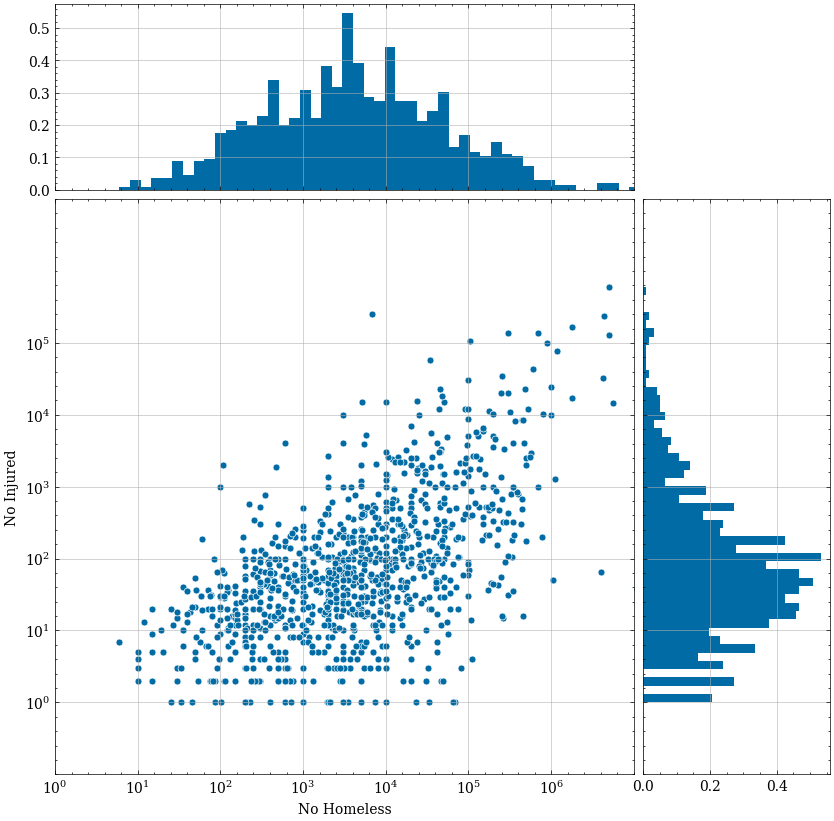

(array([3.6077756 , 1.84053864]),
 array([[1.18506413, 0.62967169],
        [0.62967169, 0.97975996]]))

In [21]:
def _plot_scatter_with_marginals(df, x_axis, y_axis, show_ellipse=True):

    use_df = df[
        (df[x_axis] > 0) &
        (df[y_axis] > 0)
    ]

    x = np.log10(use_df[x_axis].values)
    y = np.log10(use_df[y_axis].values)

    X = np.vstack([x, y]).T

    from matplotlib.gridspec import GridSpec
    fig = plt.figure(figsize=(10, 10))
    gs = GridSpec(4, 4, figure=fig, hspace=0.05, wspace=0.05)

    ax_joint = fig.add_subplot(gs[1:, 0:3])
    ax_marg_x = fig.add_subplot(gs[0, 0:3], sharex=ax_joint)
    ax_marg_y = fig.add_subplot(gs[1:, 3], sharey=ax_joint)

    ax_joint.scatter(x, y, s=25, alpha=1, edgecolors='w', linewidth=0.5)
    ax_joint.set_xlabel(f"{x_axis}")
    ax_joint.set_ylabel(f"{y_axis}")
    ax_joint.set_yticks(ticks=np.log10([1e0, 1e1, 1e2, 1e3, 1e4, 1e5]), labels=['$10^0$', '$10^1$', '$10^2$', '$10^3$', '$10^4$', '$10^5$'])
    ax_joint.set_xticks(ticks=np.log10([1e0, 1e1, 1e2, 1e3, 1e4, 1e5, 1e6]), labels=['$10^0$', '$10^1$', '$10^2$', '$10^3$', '$10^4$', '$10^5$', '$10^6$'])
    ax_joint.set_xlim(0, 7)
    ax_joint.set_ylim(-1,7)

    if show_ellipse:
        mean = X.mean(axis=0)
        cov = np.cov(X.T)
        eigenvalues, eigenvectors = np.linalg.eig(cov)
        angle = np.degrees(np.arctan2(*eigenvectors[:, 0][::-1]))

        for n_std in range(1, 4):
            width, height = 2 * n_std * np.sqrt(eigenvalues)
            ellipse = Ellipse(xy=mean, width=width, height=height, angle=angle, edgecolor='r', fc='None', lw=1, ls='--', label=f'$1/2/3 \sigma$' if n_std == 1 else "")
            ax_joint.add_patch(ellipse)
        ax_joint.legend()

    ax_marg_x.hist(x, bins=50, density=True)
    ax_marg_y.hist(y, bins=50, density=True, orientation="horizontal")

    plt.setp(ax_marg_x.get_xticklabels(), visible=False)
    plt.setp(ax_marg_y.get_yticklabels(), visible=False)
    
    save_figure(4, 5, 'multivariate', variant=f'{x_axis}_{y_axis}_ellipse{show_ellipse}')
    plt.show()
    
    return X.mean(axis=0), np.cov(X.T)

_plot_scatter_with_marginals(df, x_axis='No Homeless', y_axis='No Injured', show_ellipse=False)

Saved Fig. 4.5 -> 04_figures/4.5_multivariate/4.5_multivariate_No_Homeless_No_Injured_ellipseTrue.pdf


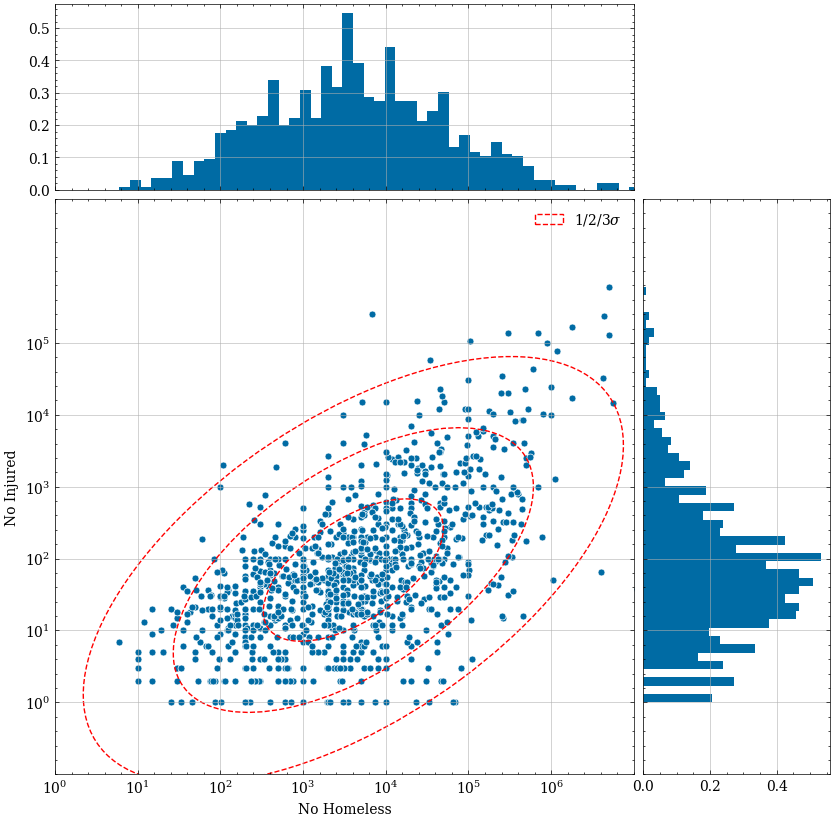

In [22]:
mean, cov = _plot_scatter_with_marginals(df, x_axis='No Homeless', y_axis='No Injured', show_ellipse=True)
